# Applications of AI

## Homework 1 - AI in Healthcare

### Marianna Kanellaki
### S-001081

####  1. Load & Inspect Dataset

In [80]:
import pandas as pd

# Load dataset
df = pd.read_csv('heart_2020_cleaned.csv')
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [81]:
# Show basic information
print("📋 Data Info:")
print(df.info())

📋 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease     

In [82]:

print("\n📊 Descriptive Statistics:")
print(df.describe())

print("\n🔍 Missing Values:")
print(df.isnull().sum())



📊 Descriptive Statistics:
                 BMI  PhysicalHealth   MentalHealth      SleepTime
count  319795.000000    319795.00000  319795.000000  319795.000000
mean       28.325399         3.37171       3.898366       7.097075
std         6.356100         7.95085       7.955235       1.436007
min        12.020000         0.00000       0.000000       1.000000
25%        24.030000         0.00000       0.000000       6.000000
50%        27.340000         0.00000       0.000000       7.000000
75%        31.420000         2.00000       3.000000       8.000000
max        94.850000        30.00000      30.000000      24.000000

🔍 Missing Values:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0

The dataset has 18 columns, 4 numerical and 14 categorical. The first column (HeartDisease) is the one we want to predict, with values Yes/No (0/1).

The dataset does not contain any missing values, so no handling is required for this.

In [83]:
# Normalize column names for easier reference
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='str')

#### 2. Encode categorical variables

In [84]:
# Split into types
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

/tmp/ipykernel_22284/1870289784.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


Our data includes 14 categorical variables such as 'Smoking', 'Sex', 'Race', etc. 

These cannot be directly used by most machine learning models, which require numerical inputs only.

So, we must convert these into numerical columns using One-hot encoding (creates binary indicator columns).

In [85]:
# Save a copy before encoding
df_before_encoding = df.copy()
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [86]:
# Apply one-hot encoding to all categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded

,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,16.60,3.0,30.0,5.0,False,True,False,False,False,False,...,True,False,True,False,False,False,True,True,False,True
1,20.34,0.0,0.0,7.0,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
2,26.58,20.0,30.0,8.0,False,True,False,False,False,True,...,True,False,True,True,False,False,False,True,False,False
3,24.21,0.0,0.0,6.0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,23.71,28.0,0.0,8.0,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,27.41,7.0,0.0,6.0,True,True,False,False,True,True,...,True,False,False,True,False,False,False,True,False,False
319791,29.84,0.0,0.0,5.0,False,True,False,False,False,True,...,False,False,True,False,False,False,True,True,False,False
319792,24.24,0.0,0.0,6.0,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
319793,32.81,0.0,0.0,12.0,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [87]:
# Convert all boolean columns to integers (0/1)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})
df_encoded

,BMI,PhysicalHealth,MentalHealth,SleepTime,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Sex_Male,...,Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,16.60,3.0,30.0,5.0,0,1,0,0,0,0,...,1,0,1,0,0,0,1,1,0,1
1,20.34,0.0,0.0,7.0,0,0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
2,26.58,20.0,30.0,8.0,0,1,0,0,0,1,...,1,0,1,1,0,0,0,1,0,0
3,24.21,0.0,0.0,6.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,23.71,28.0,0.0,8.0,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,27.41,7.0,0.0,6.0,1,1,0,0,1,1,...,1,0,0,1,0,0,0,1,0,0
319791,29.84,0.0,0.0,5.0,0,1,0,0,0,1,...,0,0,1,0,0,0,1,1,0,0
319792,24.24,0.0,0.0,6.0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
319793,32.81,0.0,0.0,12.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


#### 3.Univariate Analysis (Categorical and Numerical)

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


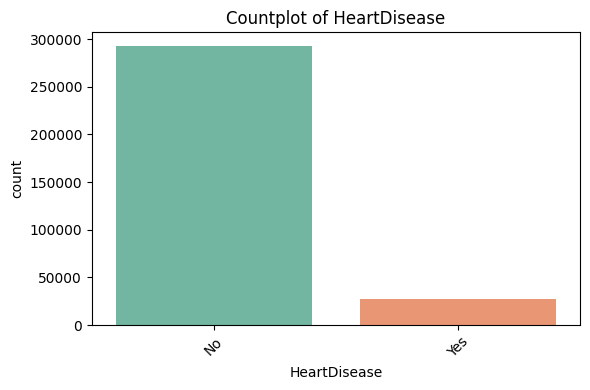

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


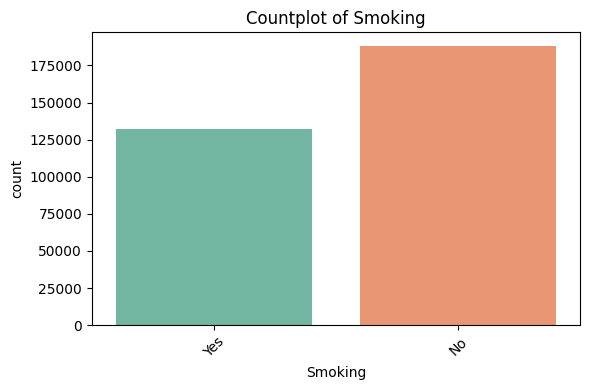

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


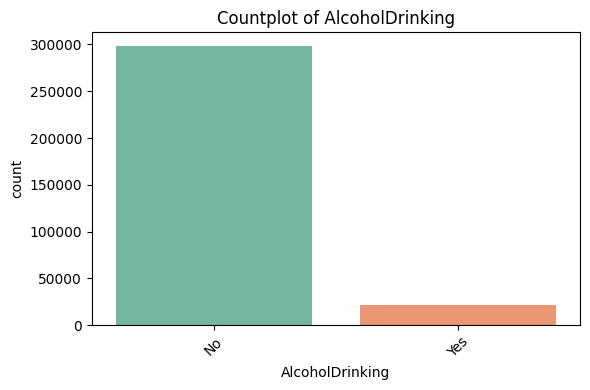

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


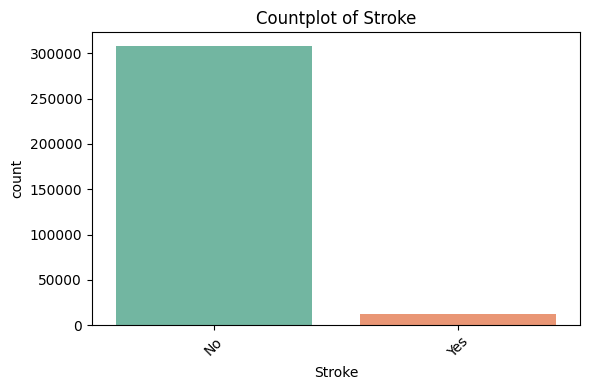

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


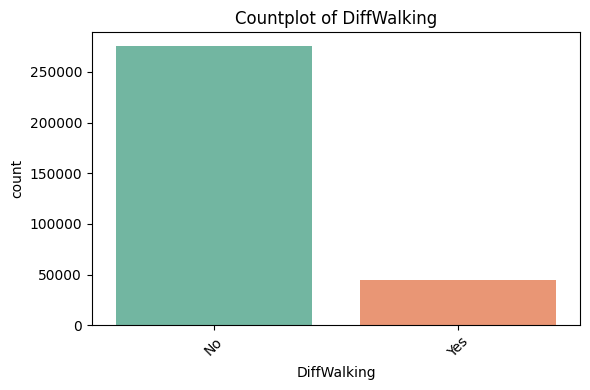

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


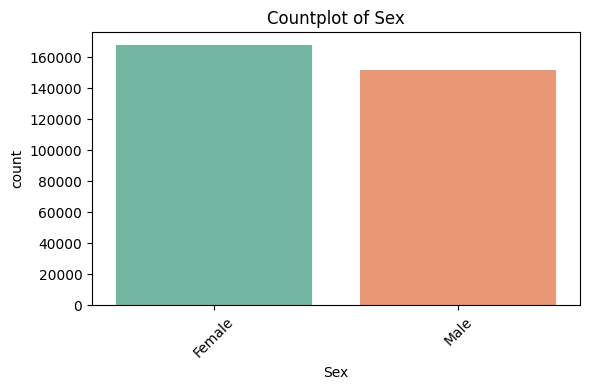

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


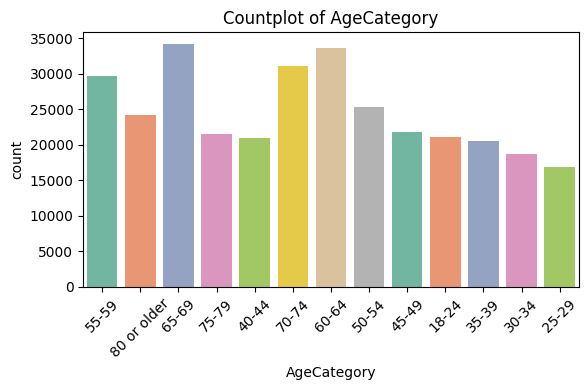

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


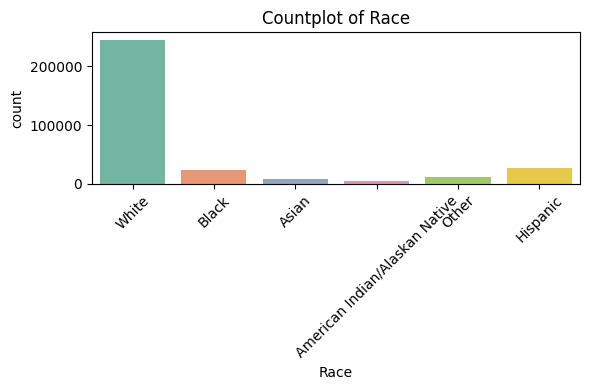

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


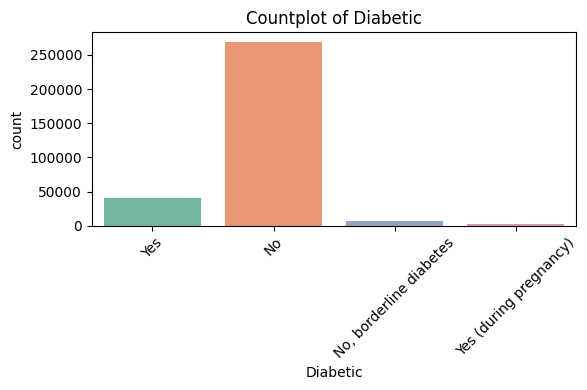

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


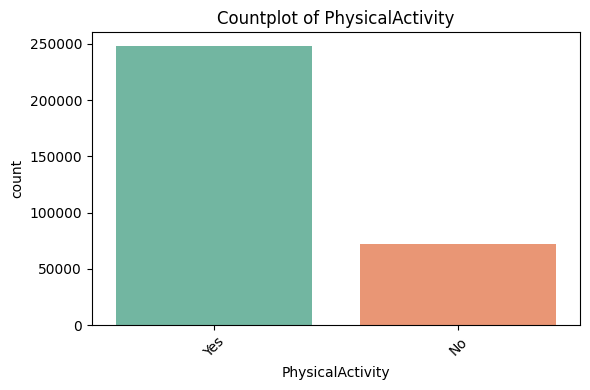

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


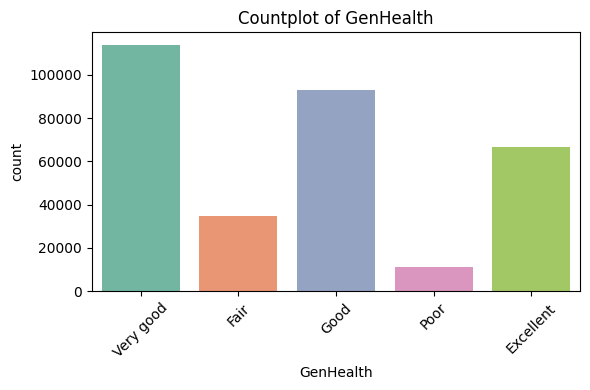

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


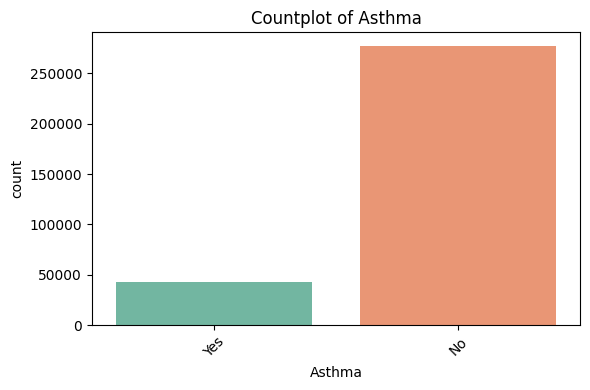

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


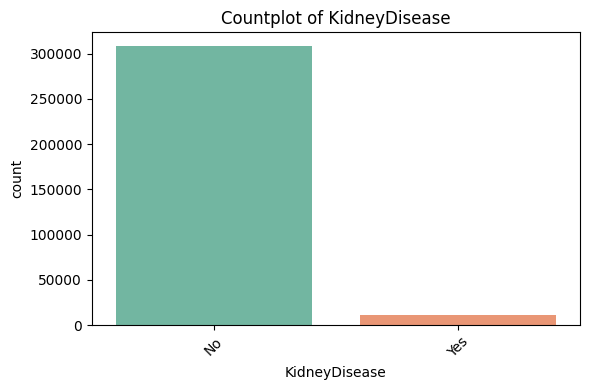

/tmp/ipykernel_22284/2714930992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


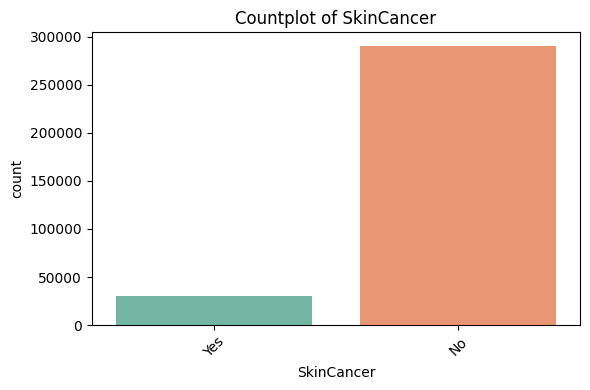

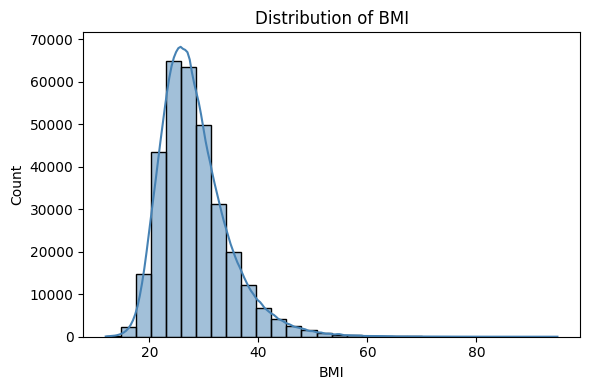

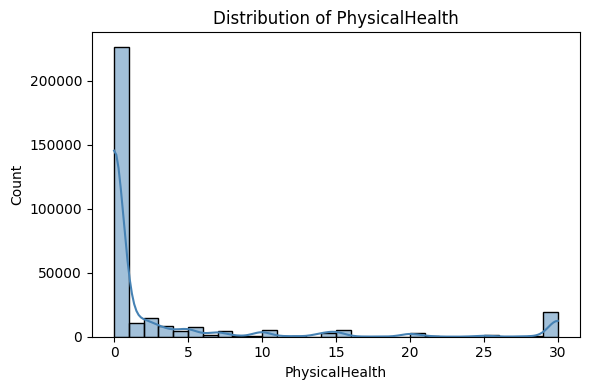

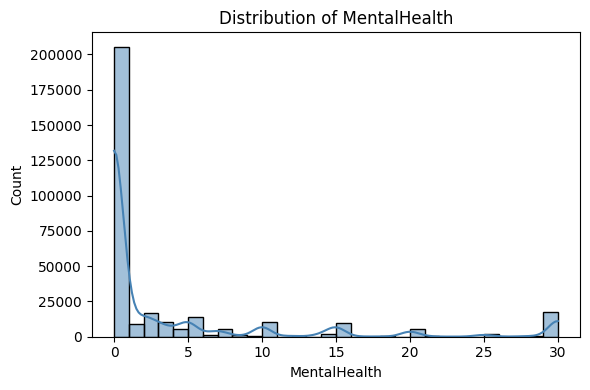

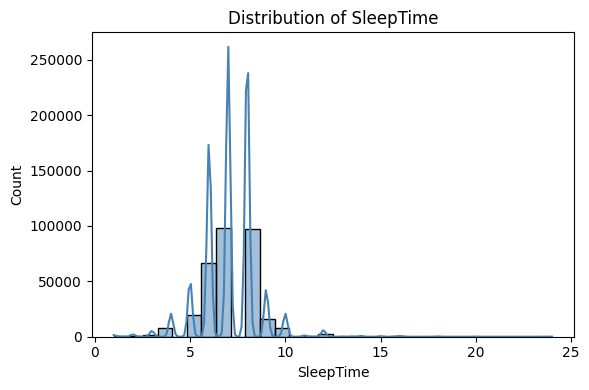

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot count plots for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot histograms for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


The univariate analysis reveals a highly imbalanced dataset, particularly concerning the target variable, where "No" cases significantly outnumber "Yes" cases. This severe class imbalance poses a challenge for predictive modeling, as the algorithm will have limited examples to learn the patterns of the ("Yes") class.

Several key demographic and lifestyle features exhibit healthy distributions. Sex is very well balanced, and age spans all groups adequately, despite slight volume variations across different groups. Similarly, continuous variables like BMI and sleep time, as well as smoking status, show relatively normal distributions.

However, many clinical and behavioral features suffer from severe underrepresentation, meaning we lack sufficient statistical power to draw robust conclusions from them. Serious medical conditions, like stroke, asthma, kidney disease, and skin cancer, are rare in this dataset. Furthermore, alcohol consumption is highly underrepresented, and the diabetic feature is heavily skewed toward "No." Demographically, the race variable is highly disproportionate, with the "White" category vastly overrepresented while all other racial groups remain heavily underrepresented.

Self-reported wellness metrics show distinct positive biases. Physical Activity leans heavily toward "Yes," and Gen Health is skewed toward positive ratings ("Good," "Very Good," and "Excellent"), with very few respondents reporting "Fair" or "Poor" health. Finally, the continuous variables for Physical Health and Mental Health (days of poor health) are skewed towards 0, meaning the vast majority of individuals reported zero issues.

#### 4. Univariate vs Heart_Attack_Outcome (Target Variable)

In [89]:
# Countplots of categorical variables vs Heart_Attack_Outcome

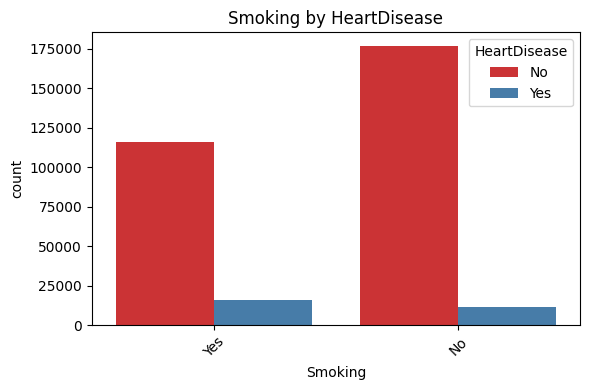

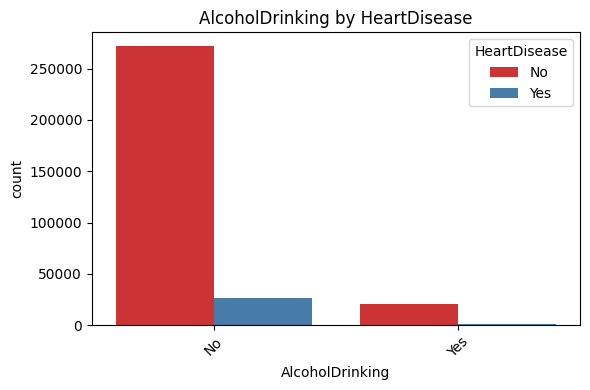

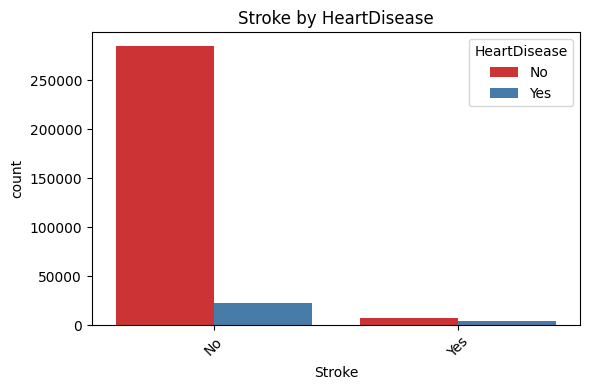

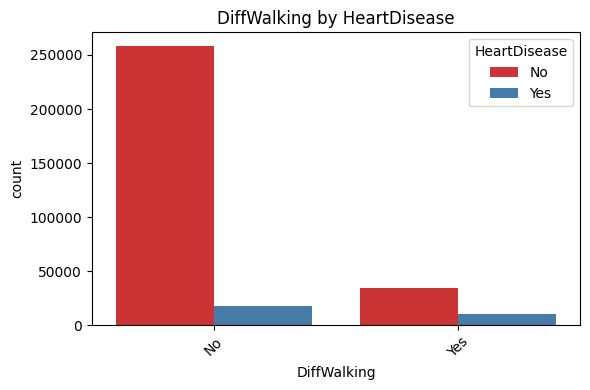

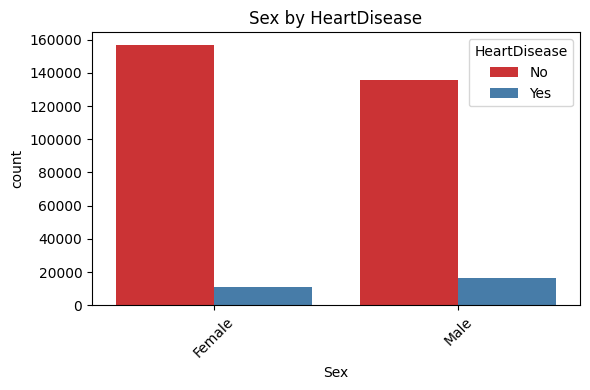

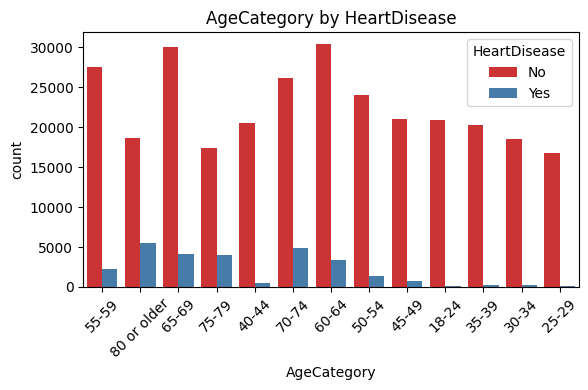

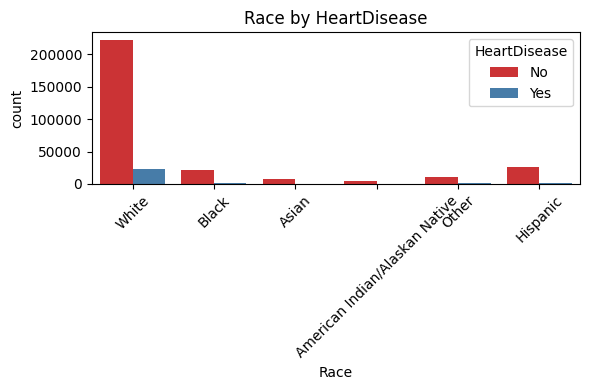

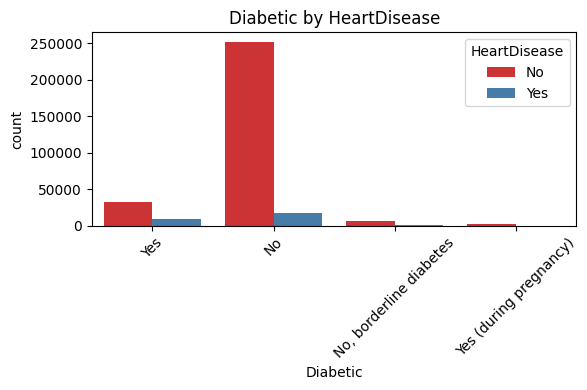

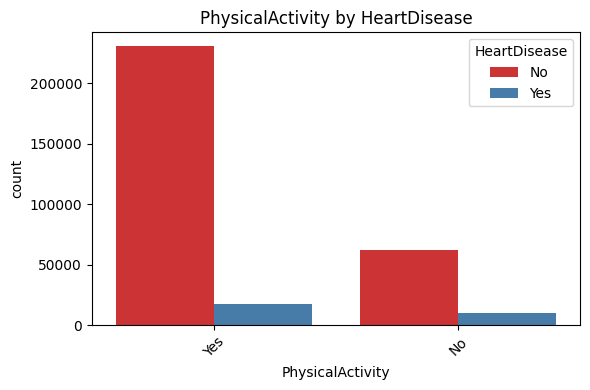

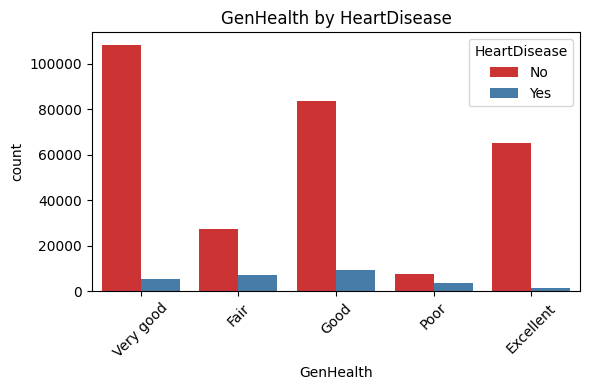

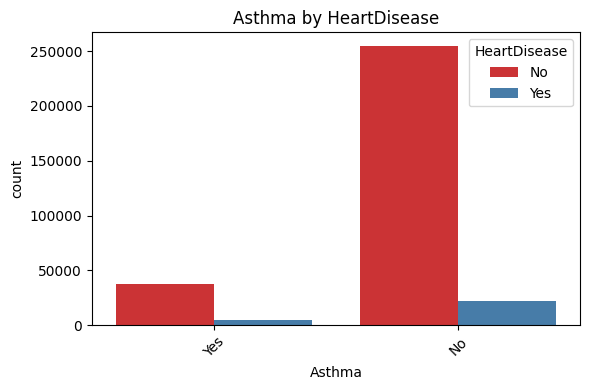

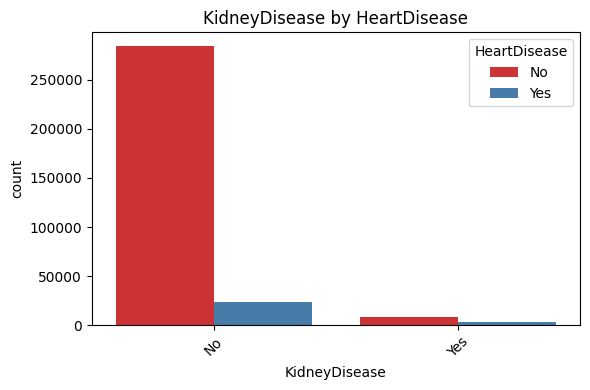

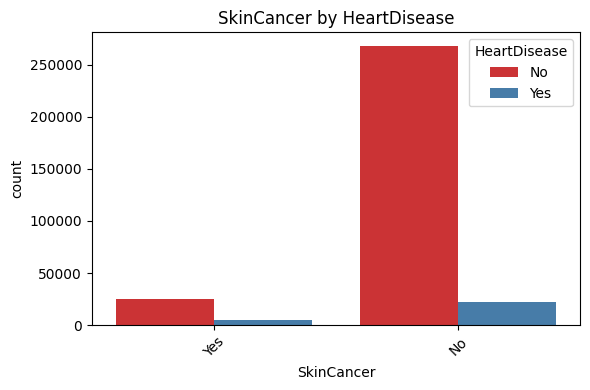

In [90]:
target = 'HeartDisease'

for col in categorical_cols:
    if col != target:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col, hue=target, palette='Set1')
        plt.title(f'{col} by {target}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


The correlation analysis of categorical variables reveals distinct predictive patterns relative to the target variable. Age, stroke, and difficulty walking demonstrate the strongest correlations, suggesting these will serve as the primary drivers for the predictive models. Several demographic and lifestyle factors, such as smoking, alcohol consumption, sex, and physical activity, show little to no linear correlation with the target in this dataset. Finally, some features (such as race, diabetes, asthma, skin cancer, and general health) are very under represented and I cannot identify any correlation at this stage. 

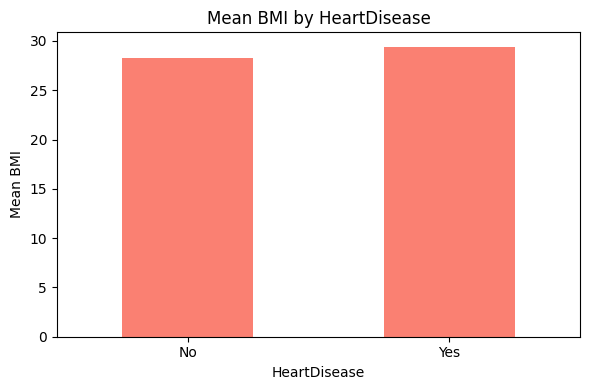

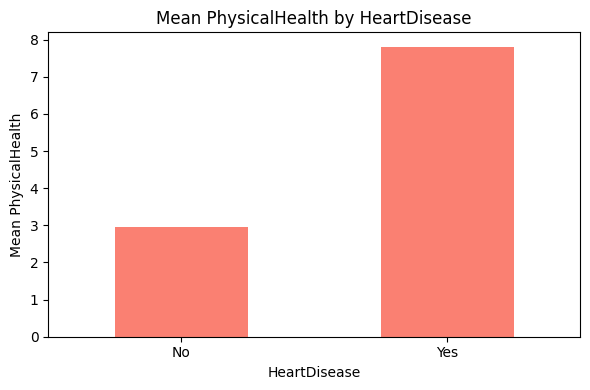

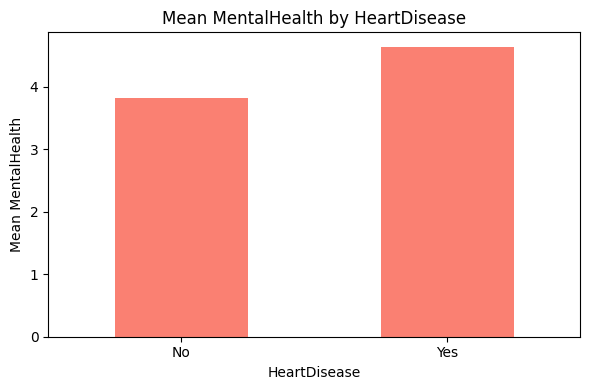

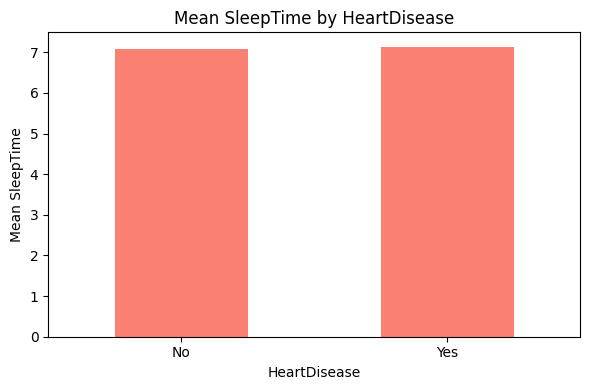

In [91]:
# Bar plots of numerical variables vs Heart_Attack_Outcome (mean values)
for col in numerical_cols:
    if col != target:
        plt.figure(figsize=(6, 4))
        df.groupby(target)[col].mean().plot(kind='bar', color='salmon')
        plt.ylabel(f'Mean {col}')
        plt.title(f'Mean {col} by {target}')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()


For the numerical features, BMI exhibits a slight upward trend among positive cases, but nothing significant. Both physical and mental health metrics (measured by the number of poor health days) show a positive correlation with the target, suggesting that an overall decline in well-being is a meaningful indicator. Finally, average dleep time demonstrates no discernible correlation with the target variable, indicating that sleep duration alone does not effectively separate the two classes in this dataset.

#### 5. Correlation Analysis with Heart_Attack_Outcome

In [92]:
# View unique values in the label column
print("Unique values in 'HeartDisease':")
print(df['HeartDisease'].unique())

# Optional: View value counts
print("\nValue counts in 'HeartDisease':")
print(df['HeartDisease'].value_counts())

Unique values in 'HeartDisease':
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Value counts in 'HeartDisease':
HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64


As mentioned above, there are significantly less cases with Heart Diseases than without, which leads to a very unbalanced dataset.

In [93]:
# Correlation matrix

/tmp/ipykernel_22284/2112257676.py:17: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


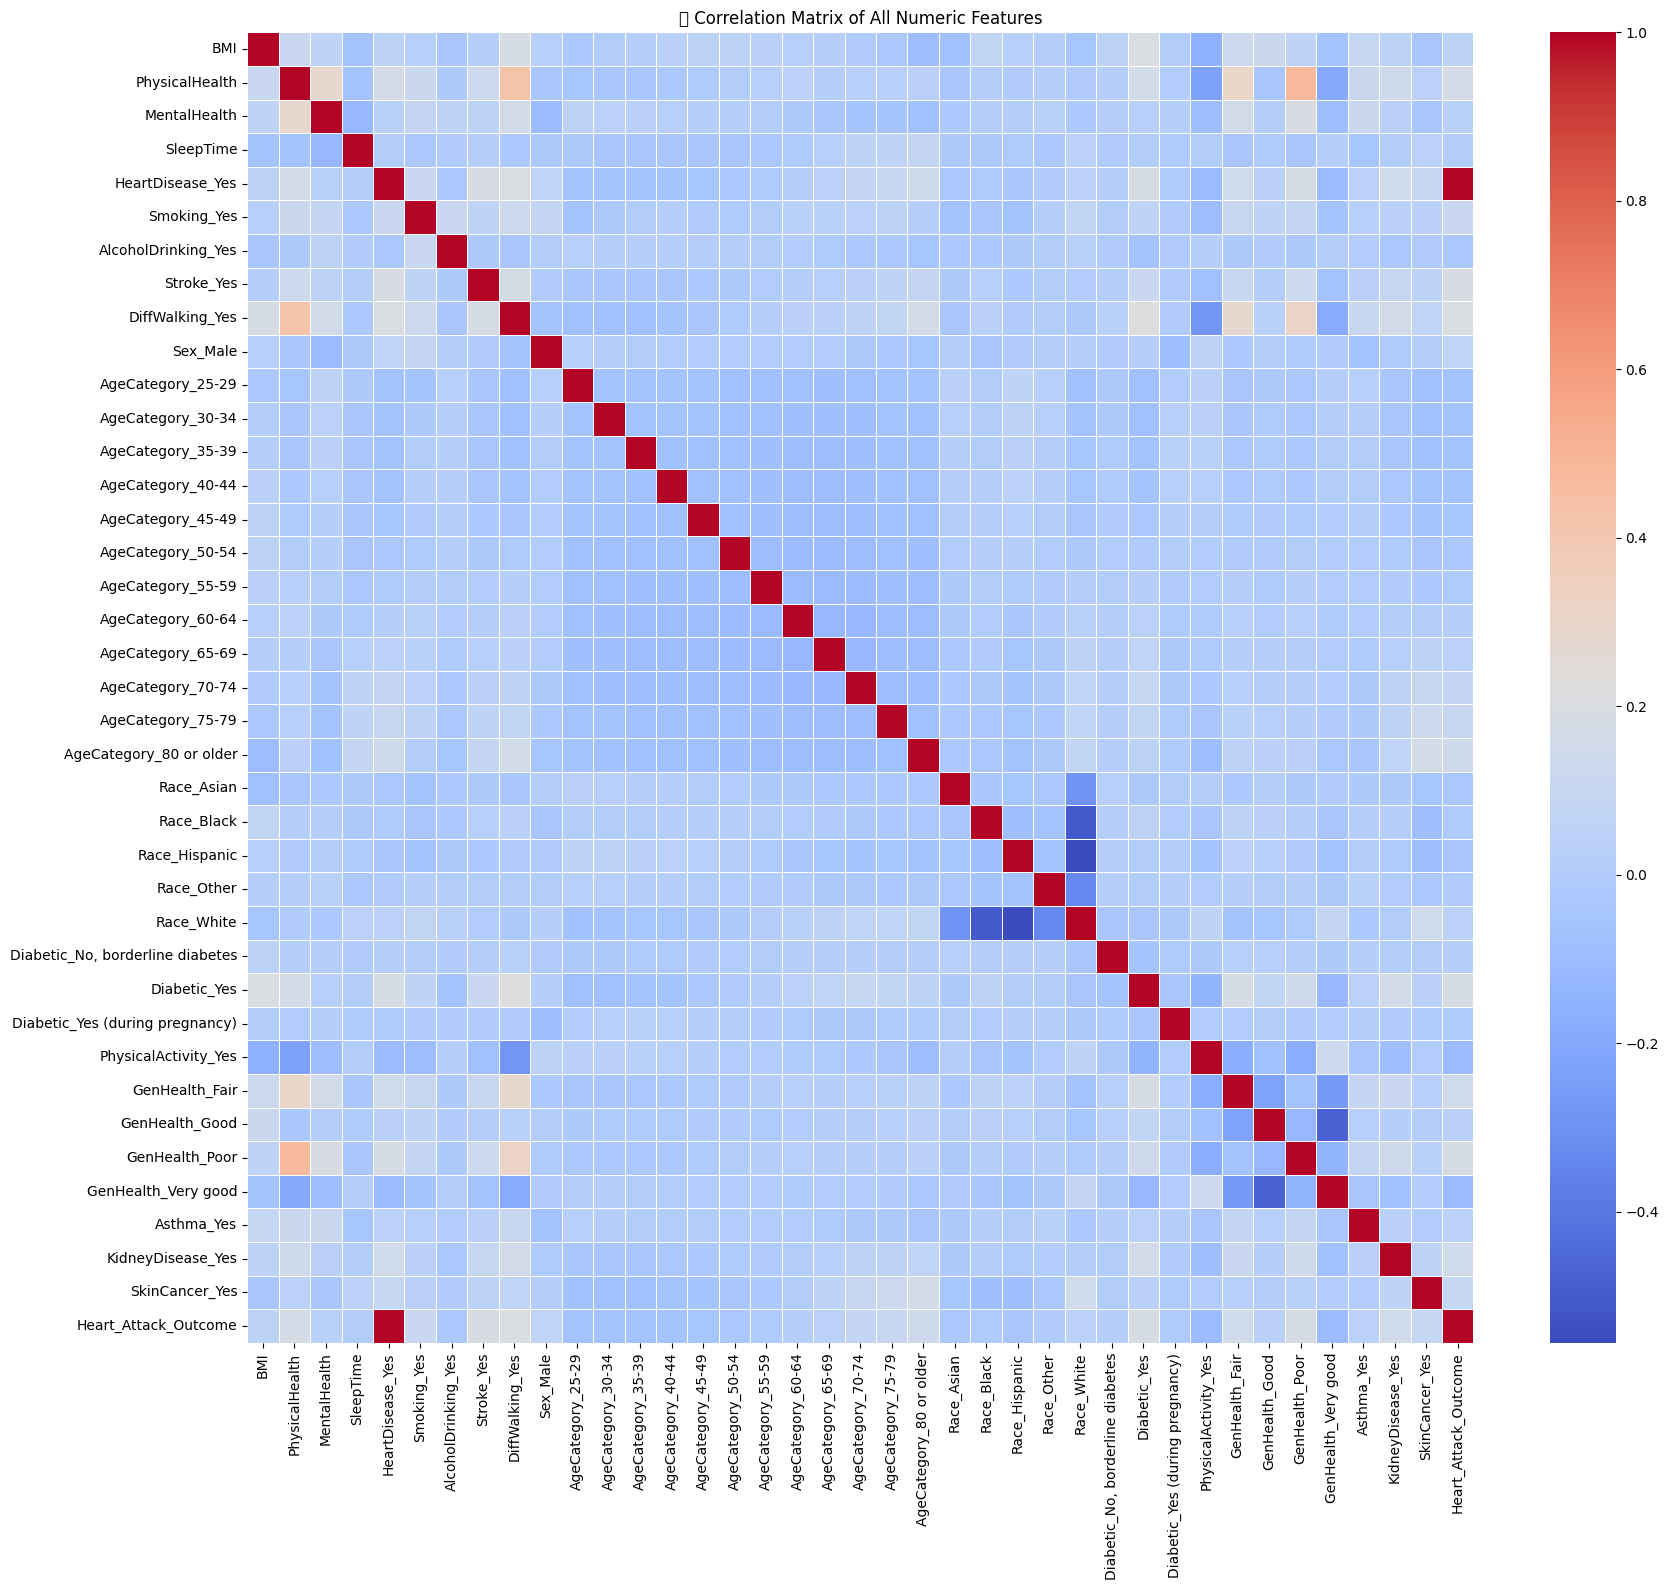

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1 Ensure target is numeric
df_encoded['Heart_Attack_Outcome'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

# Keep only numeric columns
df_numeric = df_encoded.select_dtypes(include=['int64', 'float64', 'uint8'])

# Compute correlation matrix
correlation_matrix = df_numeric.corr()

# 4 Plot full heatmap
plt.figure(figsize=(18, 16))  # Adjust size as needed
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('🔗 Correlation Matrix of All Numeric Features')
plt.tight_layout()
plt.show()


In [95]:
#  Extract correlation of all features with the target
target_corr = correlation_matrix['Heart_Attack_Outcome'].drop('Heart_Attack_Outcome')

#  Sort by absolute correlation (strongest first)
ranked_features = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

# Display ranked correlations
print("📈 Ranked features correlated with Heart_Attack_Outcome:\n")
print(ranked_features)


📈 Ranked features correlated with Heart_Attack_Outcome:

HeartDisease_Yes                    1.000000
DiffWalking_Yes                     0.201258
Stroke_Yes                          0.196835
Diabetic_Yes                        0.183072
GenHealth_Poor                      0.174662
PhysicalHealth                      0.170721
GenHealth_Fair                      0.147954
KidneyDisease_Yes                   0.145197
AgeCategory_80 or older             0.143041
Smoking_Yes                         0.107764
GenHealth_Very good                -0.101886
PhysicalActivity_Yes               -0.100030
AgeCategory_75-79                   0.098690
SkinCancer_Yes                      0.093317
AgeCategory_70-74                   0.082578
Sex_Male                            0.070040
AgeCategory_35-39                  -0.066685
AgeCategory_25-29                  -0.065759
AgeCategory_30-34                  -0.065611
AgeCategory_40-44                  -0.059196
BMI                                 0.05180

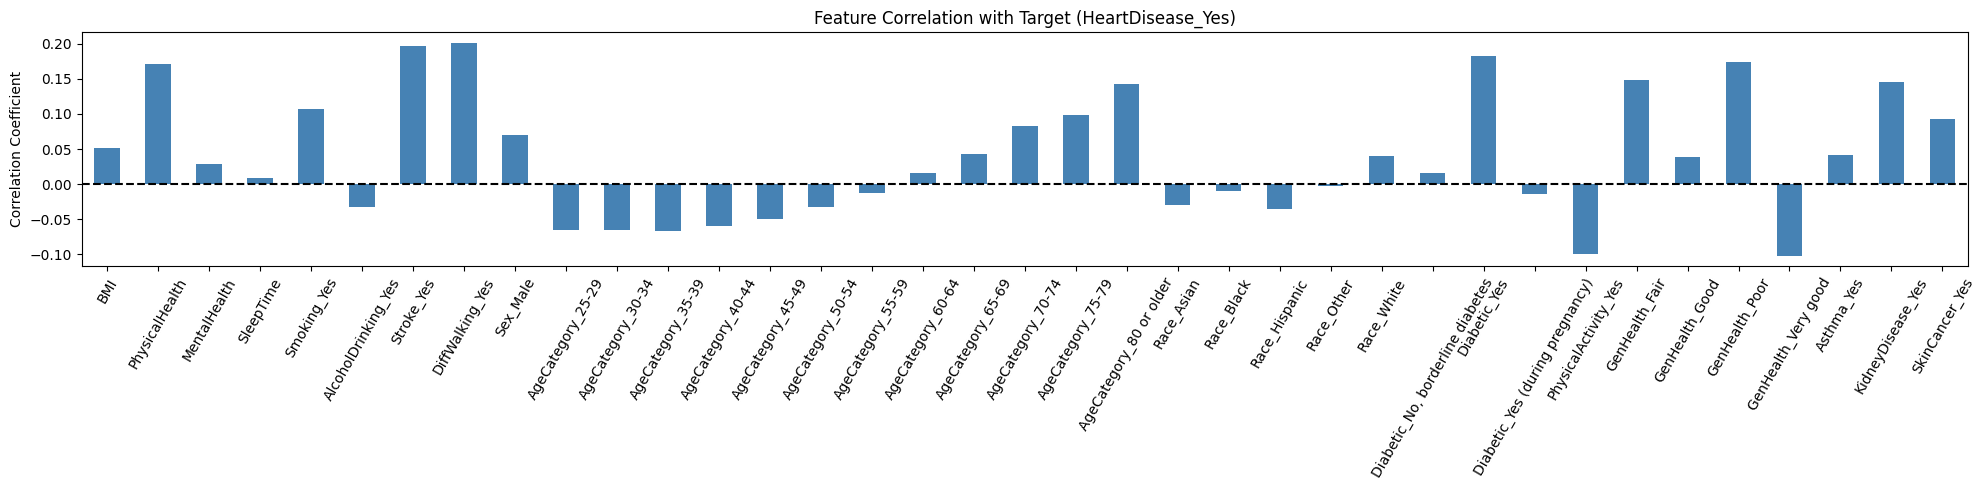

In [96]:
plt.figure(figsize=(20, 5))
target_corr.drop('HeartDisease_Yes').plot(kind='bar', color='steelblue')
plt.title("Feature Correlation with Target (HeartDisease_Yes)")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

The correlation analysis reveals that no single feature has a strong linear relationship with the target variable. The strongest predictor (DiffWalking_Yes) only reaches a correlation coefficient of 0.20. Because all linear correlations are relatively weak, it is highly likely that linear models (like Logistic Regression) will struggle. The model will need to rely on the combined, non-linear interactions of many weak signals to make accurate predictions.

The most prominent indicators of heart disease in this dataset are existing medical complications and advanced age. Specifically, difficulty walking (0.201), having a previous stroke (0.196), and being diabetic (0.183) are the top individual risk factors. Additionally, reporting "Poor" general health (0.174) and being in the "80 or older" age category (0.143) show the strongest positive relationships with the target.

The data also highlights specific lifestyle and health statuses that act as protective indicators. Engaging in physical activity (-0.100) and reporting "Very good" general health (-0.101) show the strongest inverse relationships with heart disease. Furthermore, being in younger age brackets (specifically those under 50, such as ages 25-44) correlates negatively with the target.

Finally, several features demonstrate almost zero linear relationship with heart disease outcomes. Variables such as sleep time (0.008), mild alcohol consumption (-0.032), and race categories do not show any meaningful linear predictive value on their own.

#### 6. Train ML Models

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import set_random_seed
import numpy as np

# Drop both original and one-hot encoded target columns
X = df_encoded.drop(['HeartDisease', 'Heart_Attack_Outcome', 'HeartDisease_Yes'], axis=1, errors='ignore')
y = df_encoded['Heart_Attack_Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features for same feature importance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [98]:
y


0         0
1         0
2         0
3         0
4         0
         ..
319790    1
319791    0
319792    0
319793    0
319794    0
Name: Heart_Attack_Outcome, Length: 319795, dtype: int64

##### Classical ML Methods

- Logistic Regression
- Random Forest
- XGBoost
- Naive Bayes

In [99]:
results = []

ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
                    scale_pos_weight=0.8, 
                    learning_rate=0.01,  
                    colsample_bytree = 0.9,
                    subsample = 0.8,
                    objective='binary:logistic', 
                    n_estimators=1000, 
                    reg_alpha = 0.3,
                    max_depth=5, 
                    gamma=1,
                    min_child_weight=6,
                    random_state=42,
                    seed=27
    ),
    "Naive Bayes": GaussianNB(),
}

In [100]:
for model_name, model in ml_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # 2. Append the results as a dictionary
    results.append({
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "preds": y_pred
    })

/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
df_results = pd.DataFrame(results).sort_values(by="accuracy", ascending=False).reset_index(drop=True)
df_results.loc[:, df_results.columns != 'preds']

,model,accuracy,precision,recall,f1_score
0,XGBoost,0.914445,0.614943,0.057403,0.105005
1,Logistic Regression,0.913867,0.539336,0.101753,0.171205
2,Random Forest,0.902985,0.344179,0.121066,0.179124
3,Naive Bayes,0.733110,0.210269,0.744814,0.327953


From the classical ML models, when looking solely at the accuracy, all models perform very well except Naive Bayes, with XGBoost being the best performing one.

When looking at the other metrics as well and most importantly the recall, we can clearly see the effects of the class imbalance. While XGBoost achieved the highest overall Accuracy (91.4%) and Precision (55.8%), it suffered from very low Recall (5.7%). This indicates that the model is highly conservative and achieves high accuracy by predicting mostly the majority class ("No Heart Attack"). Logistic Regression and Random Forest exhibited similar behaviors, though showing a higher recall (10.17% and 12.1%). Naive Bayes demonstrated the opposite behaviour: it successfully caught 74.48% of all heart attack cases (highest recall) but sacrificed accuracy (73.3%) and precision (21.02%) by over-predicting the positive class.

The reasons behind these behaviours are that when a dataset is highly imbalanced, most algorithms realize that predicting the under-represented class is risky. If it guesses the over-represented class for every single person, it guarantees itself a 90% accuracy rate and a very low loss score. Therefore, most models become conservative, only predicting "Yes" when the evidence from the features is overwhelming.

Naive Bayes behaves completely differently, yielding high recall and low precision. This happens because of the independence assumption of the algorithm, i.e. Naive Bayes assumes that every single feature is completely independent of the others. It multiplies these probabilities together, inflating the final probability of a heart attack. This causes the model to over-predict the positive class, catching almost many who actually had a heart attack, but falsely diagnosing a big amount of healthy people in the process.

##### DL Methods

##### 1. Demo Deep Neural Network (5 Layers)

In [102]:
from tensorflow.keras.callbacks import EarlyStopping

set_random_seed(42)  # for reproducibility

dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

dnn_model.fit(X_train_scaled, y_train, validation_split=0.2,
              epochs=10, batch_size=256, verbose=1,
              callbacks=[EarlyStopping(patience=2, restore_best_weights=True)])

Epoch 1/10


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9109 - loss: 0.2466 - val_accuracy: 0.9159 - val_loss: 0.2271
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9161 - loss: 0.2287 - val_accuracy: 0.9161 - val_loss: 0.2262
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9163 - loss: 0.2269 - val_accuracy: 0.9158 - val_loss: 0.2260
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9164 - loss: 0.2263 - val_accuracy: 0.9160 - val_loss: 0.2259
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9162 - loss: 0.2255 - val_accuracy: 0.9161 - val_loss: 0.2258
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9164 - loss: 0.2250 - val_accuracy: 0.9161 - val_loss: 0.2260
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9164 - loss: 0.2246 - val_accuracy: 0.9164 - val_loss: 0.2256
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9164 - loss: 0.2241 - val_accuracy: 0.9160 - val_

In [103]:
dnn_preds = (dnn_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
results.append({
    "model": "Demo DNN",
    "accuracy": accuracy_score(y_test, dnn_preds),
    "precision": precision_score(y_test, dnn_preds, zero_division=0),
    "recall": recall_score(y_test, dnn_preds),
    "f1_score": f1_score(y_test, dnn_preds),
    "preds": dnn_preds
})

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 1s 433us/step


##### 2. Bonus Deep Neural Network

In [104]:
set_random_seed(42)  # for reproducibility

bonus_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'), #, input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    # Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

bonus_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bonus_model.fit(X_train_scaled, y_train, validation_split=0.2,
                epochs=20, batch_size=256, verbose=1,
                callbacks=[EarlyStopping(patience=2, restore_best_weights=True)])

bonus_preds = (bonus_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
bonus_acc = accuracy_score(y_test, bonus_preds)

Epoch 1/20


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9147 - loss: 0.2436 - val_accuracy: 0.9141 - val_loss: 0.2345
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9151 - loss: 0.2308 - val_accuracy: 0.9141 - val_loss: 0.2322
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9153 - loss: 0.2287 - val_accuracy: 0.9157 - val_loss: 0.2330
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9157 - loss: 0.2274 - val_accuracy: 0.9159 - val_loss: 0.2297
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9160 - loss: 0.2257 - val_accuracy: 0.9155 - val_loss: 0.2279
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9159 - loss: 0.2257 - val_accuracy: 0.9157 - val_loss: 0.2278
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9162 - loss: 0.2252 - val_accuracy: 0.9154 - val_loss: 0.2295
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9162 - loss: 0.2247 - val_accuracy: 0.9154 - val_

I tried a few different activation functions but stuck with relu that had the best results.

In [105]:
bonus_preds = (bonus_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
results.append({
    "model": "Bonus DNN",
    "accuracy": accuracy_score(y_test, bonus_preds),
    "precision": precision_score(y_test, bonus_preds, zero_division=0),
    "recall": recall_score(y_test, bonus_preds),
    "f1_score": f1_score(y_test, bonus_preds),
    "preds": bonus_preds
})

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 1s 435us/step


In [106]:
df_results = pd.DataFrame(results).sort_values(by="accuracy", ascending=False).reset_index(drop=True)
df_results.loc[:, df_results.columns != 'preds']

,model,accuracy,precision,recall,f1_score
0,XGBoost,0.914445,0.614943,0.057403,0.105005
1,Bonus DNN,0.914148,0.586919,0.060980,0.110481
2,Demo DNN,0.914132,0.568493,0.074213,0.131288
3,Logistic Regression,0.913867,0.539336,0.101753,0.171205
4,Random Forest,0.902985,0.344179,0.121066,0.179124
5,Naive Bayes,0.733110,0.210269,0.744814,0.327953


XGBoost (91.44%) and the two Deep Neural Networks (~91.41%) achieve more or less the same accuracy. The best balance (F1 score) is achieved by Naive Bayes (0.327), followed by Random Forest (0.179) and Logistic Regression (0.171).

Logistic Regression achieves near-peak accuracy (91.38%) and a better F1 score than the DNNs, making it the most efficient model among the higher accuracy ones.

For this specific dataset, Traditional Machine Learning is superior. The Deep Learning models perform adequately in raw accuracy, but they do not outperform the best traditional ML techniques. A traditional approach like XGBoost (for maximum precision/accuracy) or Logistic Regression (for an efficient, interpretable baseline) is the better choice.

##### Confusion Matrix of the 2 Best Models


Top 2 Models:
1st Place: XGBoost (Accuracy: 0.9144)
2nd Place: Bonus DNN (Accuracy: 0.9141)
----------------------------------------
Breakdown for: XGBoost
----------------------------------------
True Negatives (TN) : 58,166
False Positives (FP): 201
False Negatives (FN): 5,271
True Positives (TP) : 321
----------------------------------------
Precision: 0.6149
-> About 61.5% of predicted Heart Disease cases were actually correct.

Recall: 0.0574
-> Only 5.7% of actual Heart Disease cases were identified.
----------------------------------------
Breakdown for: Bonus DNN
----------------------------------------
True Negatives (TN) : 58,127
False Positives (FP): 240
False Negatives (FN): 5,251
True Positives (TP) : 341
----------------------------------------
Precision: 0.5869
-> About 58.7% of predicted Heart Disease cases were actually correct.

Recall: 0.0610
-> Only 6.1% of actual Heart Disease cases were identified.


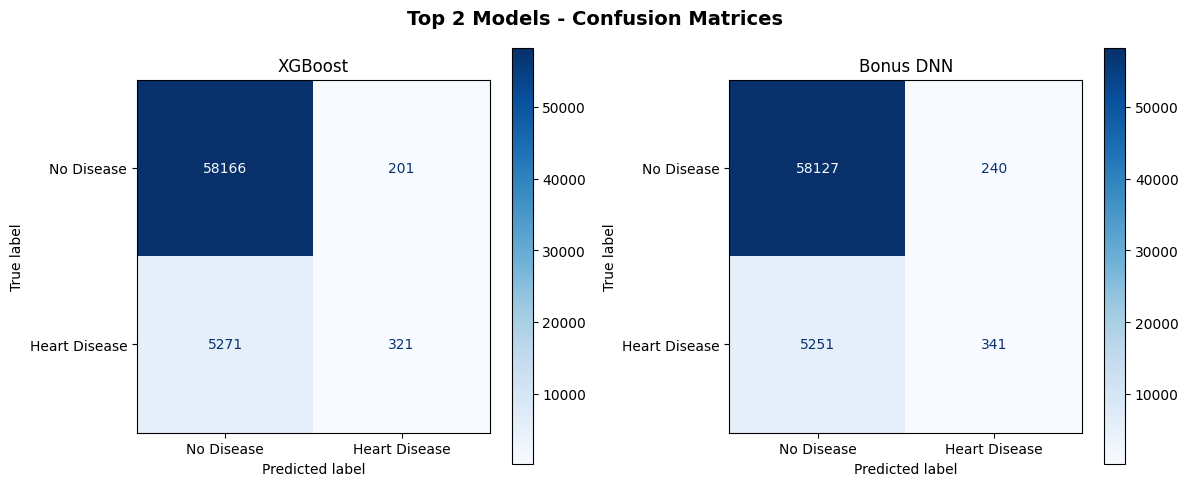

In [120]:
sorted_results = sorted(results, key=lambda x: x['accuracy'], reverse=True)

top_2_models = sorted_results[:2]

print("\nTop 2 Models:")
print(f"1st Place: {top_2_models[0]['model']} (Accuracy: {top_2_models[0]['accuracy']:.4f})")
print(f"2nd Place: {top_2_models[1]['model']} (Accuracy: {top_2_models[1]['accuracy']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, model_data in enumerate(top_2_models):
    model_name = model_data['model']
    best_preds = model_data['preds']
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{model_name}")

    tn, fp, fn, tp = cm.ravel()

    print("-" * 40)
    print(f"Breakdown for: {model_name}")
    print("-" * 40)
    print(f"True Negatives (TN) : {tn:,}")
    print(f"False Positives (FP): {fp:,}")
    print(f"False Negatives (FN): {fn:,}")
    print(f"True Positives (TP) : {tp:,}")
    print("-" * 40)

    print(f"Precision: {top_2_models[i]['precision']:.4f}")
    print(f"-> About {top_2_models[i]['precision'] * 100:.1f}% of predicted Heart Disease cases were actually correct.\n")

    print(f"Recall: {top_2_models[i]['recall']:.4f}")
    print(f"-> Only {top_2_models[i]['recall'] * 100:.1f}% of actual Heart Disease cases were identified.")

plt.suptitle("Top 2 Models - Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Although both XGBoost and the Bonus Deep Neural Network achieved a high accuracy of over 91%, with the confusion matrices we can observe how severe is the class imbalance in the dataset. With over 58,000 negative cases compared to roughly 5,500 positive cases, the models achieved high accuracy by mostly predicting the majority "No Heart Disease" class. XGBoost successfully identified only 5.7% of actual heart disease cases, while the DNN only the 6.1%, meaning both models missed nearly 94% of sick patients.

In order to overcome the class imbalance, I will try the SMOTE technique, and copy paste all the cells from above to compare performances with and without SMOTE.

## SMOTE Attempt

##### Exact same cells but with SMOTE applied to training data

In [108]:
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Heart_Attack_Outcome
0    234055
1     21781
Name: count, dtype: int64

After SMOTE:
Heart_Attack_Outcome
0    234055
1    234055
Name: count, dtype: int64


##### Classical ML Methods

- Logistic Regression
- Random Forest
- XGBoost
- Naive Bayes

In [109]:
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
                    scale_pos_weight=0.8, 
                    learning_rate=0.01,  
                    colsample_bytree = 0.9,
                    subsample = 0.8,
                    objective='binary:logistic', 
                    n_estimators=1000, 
                    reg_alpha = 0.3,
                    max_depth=5, 
                    gamma=1,
                    min_child_weight=6,
                    random_state=42,
                    seed=27
    ),
    "Naive Bayes": GaussianNB(),
}

In [110]:
for model_name, model in ml_models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # 2. Append the results as a dictionary
    results.append({
        "model": model_name+" SMOTE",
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "preds": y_pred
    })

/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
df_results = pd.DataFrame(results).sort_values(by="f1_score", ascending=False).reset_index(drop=True)
df_results.loc[:, df_results.columns != 'preds']

,model,accuracy,precision,recall,f1_score
0,Logistic Regression SMOTE,0.751372,0.228456,0.775572,0.352946
1,Naive Bayes,0.733110,0.210269,0.744814,0.327953
2,XGBoost SMOTE,0.889070,0.345656,0.300966,0.321767
3,Naive Bayes SMOTE,0.624009,0.169366,0.845315,0.282192
4,Random Forest SMOTE,0.875874,0.270756,0.247854,0.258799
5,Random Forest,0.902985,0.344179,0.121066,0.179124
6,Logistic Regression,0.913867,0.539336,0.101753,0.171205
7,Demo DNN,0.914132,0.568493,0.074213,0.131288
8,Bonus DNN,0.914148,0.586919,0.060980,0.110481
9,XGBoost,0.914445,0.614943,0.057403,0.105005


All the models using the SMOTE dataset show less accuracy and precision, but really improved recall and f1 score. So the dataset over sampling really help improve the results overall. The Logistic Regression with SMOTE showed the best balance (f1 score), with the Naive Bayes and Logistic Regression achieving the best recall (84.53% and 77,55%).

##### DL Methods

##### 1. Demo Deep Neural Network (5 Layers)

In [112]:
from tensorflow.keras.callbacks import EarlyStopping

set_random_seed(42)  # for reproducibility

dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_smote.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

dnn_model.fit(X_train_smote, y_train_smote, validation_split=0.2,
              epochs=10, batch_size=256, verbose=1,
              callbacks=[EarlyStopping(patience=2, restore_best_weights=True)])

Epoch 1/10


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1463/1463 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7663 - loss: 0.4812 - val_accuracy: 0.7000 - val_loss: 0.6387
Epoch 2/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7770 - loss: 0.4625 - val_accuracy: 0.6990 - val_loss: 0.6130
Epoch 3/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7800 - loss: 0.4570 - val_accuracy: 0.7123 - val_loss: 0.5930
Epoch 4/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7826 - loss: 0.4525 - val_accuracy: 0.7221 - val_loss: 0.5715
Epoch 5/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7857 - loss: 0.4472 - val_accuracy: 0.7412 - val_loss: 0.5551
Epoch 6/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7884 - loss: 0.4421 - val_accuracy: 0.7473 - val_loss: 0.5442
Epoch 7/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7909 - loss: 0.4371 - val_accuracy: 0.7637 - val_loss: 0.5288
Epoch 8/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7937 - loss: 0.4309 - val_accurac

In [113]:
dnn_preds = (dnn_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
results.append({
    "model": "Demo DNN SMOTE",
    "accuracy": accuracy_score(y_test, dnn_preds),
    "precision": precision_score(y_test, dnn_preds, zero_division=0),
    "recall": recall_score(y_test, dnn_preds),
    "f1_score": f1_score(y_test, dnn_preds),
    "preds": dnn_preds
})

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step


##### 2. Bonus Deep Neural Network

In [114]:
set_random_seed(42)  # for reproducibility

bonus_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'), #, input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    # Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

bonus_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bonus_model.fit(X_train_scaled, y_train, validation_split=0.2,
                epochs=20, batch_size=256, verbose=1,
                callbacks=[EarlyStopping(patience=2, restore_best_weights=True)])

bonus_preds = (bonus_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
bonus_acc = accuracy_score(y_test, bonus_preds)

Epoch 1/20


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9147 - loss: 0.2436 - val_accuracy: 0.9141 - val_loss: 0.2345
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9151 - loss: 0.2308 - val_accuracy: 0.9141 - val_loss: 0.2322
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9153 - loss: 0.2287 - val_accuracy: 0.9157 - val_loss: 0.2330
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9157 - loss: 0.2274 - val_accuracy: 0.9159 - val_loss: 0.2297
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9160 - loss: 0.2257 - val_accuracy: 0.9155 - val_loss: 0.2279
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9159 - loss: 0.2257 - val_accuracy: 0.9157 - val_loss: 0.2278
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9162 - loss: 0.2252 - val_accuracy: 0.9154 - val_loss: 0.2295
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9162 - loss: 0.2247 - val_accuracy: 0.9154 - val_

I tried a few different activation functions but stuck with relu that had the best results.

In [115]:
bonus_preds = (bonus_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()
results.append({
    "model": "Bonus DNN SMOTE",
    "accuracy": accuracy_score(y_test, bonus_preds),
    "precision": precision_score(y_test, bonus_preds, zero_division=0),
    "recall": recall_score(y_test, bonus_preds),
    "f1_score": f1_score(y_test, bonus_preds),
    "preds": bonus_preds
})

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 1s 451us/step


In [118]:
df_results = pd.DataFrame(results).sort_values(by="f1_score", ascending=False).reset_index(drop=True)
df_results.loc[:, df_results.columns != 'preds']

,model,accuracy,precision,recall,f1_score
0,Demo DNN SMOTE,0.810707,0.260355,0.632868,0.368934
1,Logistic Regression SMOTE,0.751372,0.228456,0.775572,0.352946
2,Naive Bayes,0.733110,0.210269,0.744814,0.327953
3,XGBoost SMOTE,0.889070,0.345656,0.300966,0.321767
4,Naive Bayes SMOTE,0.624009,0.169366,0.845315,0.282192
5,Random Forest SMOTE,0.875874,0.270756,0.247854,0.258799
6,Random Forest,0.902985,0.344179,0.121066,0.179124
7,Logistic Regression,0.913867,0.539336,0.101753,0.171205
8,Demo DNN,0.914132,0.568493,0.074213,0.131288
9,Bonus DNN,0.914148,0.586919,0.060980,0.110481


The smaller DNN (from the demo), also showed an improved balance (f1 score) and recall, achieving actually the best balance of all models (36%) and a recall of 63%.

##### Confusion Matrix of the 2 most balanced Models (best f1)


2 Most Balanced Models:
1st Place: Demo DNN SMOTE (F1: 0.3689)
2nd Place: Logistic Regression SMOTE (F1: 0.3529)
----------------------------------------
Breakdown for: Demo DNN SMOTE
----------------------------------------
True Negatives (TN) : 48,313
False Positives (FP): 10,054
False Negatives (FN): 2,053
True Positives (TP) : 3,539
----------------------------------------
Precision: 0.2604
-> About 26.0% of predicted Heart Disease cases were actually correct.

Recall: 0.6329
-> 63.3% of actual Heart Disease cases were identified.
----------------------------------------
Breakdown for: Logistic Regression SMOTE
----------------------------------------
True Negatives (TN) : 43,720
False Positives (FP): 14,647
False Negatives (FN): 1,255
True Positives (TP) : 4,337
----------------------------------------
Precision: 0.2285
-> About 22.8% of predicted Heart Disease cases were actually correct.

Recall: 0.7756
-> 77.6% of actual Heart Disease cases were identified.


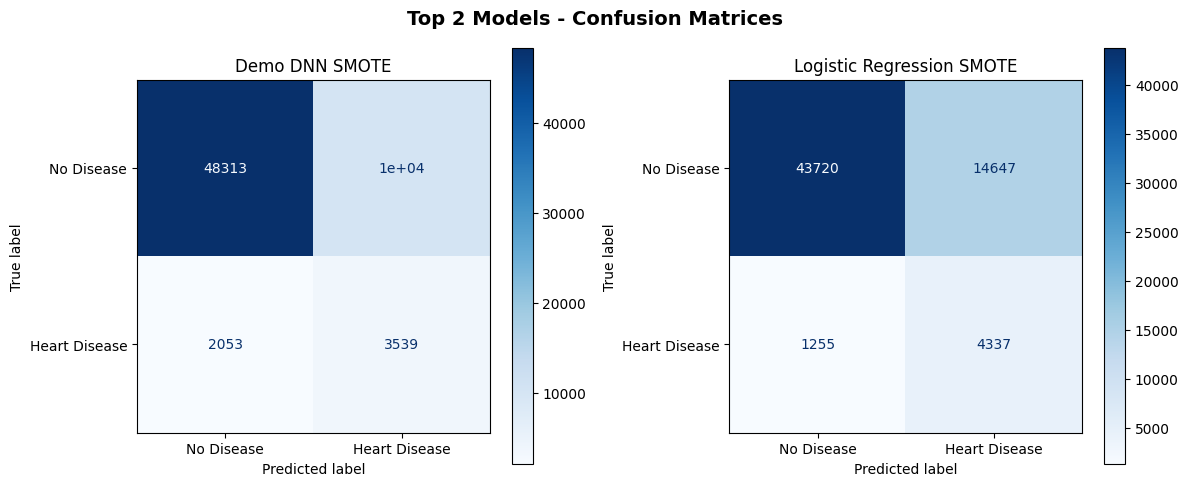

In [122]:
sorted_results = sorted(results, key=lambda x: x['f1_score'], reverse=True)

top_2_models = sorted_results[:2]

print("\n2 Most Balanced Models:")
print(f"1st Place: {top_2_models[0]['model']} (F1: {top_2_models[0]['f1_score']:.4f})")
print(f"2nd Place: {top_2_models[1]['model']} (F1: {top_2_models[1]['f1_score']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, model_data in enumerate(top_2_models):
    model_name = model_data['model']
    best_preds = model_data['preds']
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{model_name}")

    tn, fp, fn, tp = cm.ravel()

    print("-" * 40)
    print(f"Breakdown for: {model_name}")
    print("-" * 40)
    print(f"True Negatives (TN) : {tn:,}")
    print(f"False Positives (FP): {fp:,}")
    print(f"False Negatives (FN): {fn:,}")
    print(f"True Positives (TP) : {tp:,}")
    print("-" * 40)

    print(f"Precision: {top_2_models[i]['precision']:.4f}")
    print(f"-> About {top_2_models[i]['precision'] * 100:.1f}% of predicted Heart Disease cases were actually correct.\n")

    print(f"Recall: {top_2_models[i]['recall']:.4f}")
    print(f"-> {top_2_models[i]['recall'] * 100:.1f}% of actual Heart Disease cases were identified.")

plt.suptitle("Top 2 Models - Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Applying SMOTE has hifted how these models operate, successfully making them recognize the minority class. The most critical improvement is the massive jump in recall; instead of missing nearly 94% of sick patients like the original models, Logistic Regression now successfully identifies 77.6% of actual heart disease cases, and the Deep Neural Network catches 63.3%. 

However, this increased recall has a cost to precision. Both models are now generating a significant number of false positives over 10,000 for the DNN and nearly 15,000 for Logistic Regression.